# Fig S10. representation drift

In [1]:
from util import fisherztrans,stat_m_e,pair_test,sig,color_inv_alpha,corr_batch_nan
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from faceprf_figure_function import set_figure,set_ax,myviolinplot_ind,myviolinplot_pair,myviolinplot_multi
import pingouin
import statsmodels.formula.api as smf

# setting
nsubj = 8
npos = 16
task = ['Digit Task','Face Task']
roi_labels = ['V1','V2','V3','hV4','IOG','pFus','mFus']
nroi = len(roi_labels)
ntask = len(task)

cms=np.array([[255, 195, 73],[145, 115, 185]])/255

# data path
data_path = "../data/"

# load data
data = np.load(f'{data_path}/driftcheck.npz')
beta_session = data['beta_session']
glm_r2_all = data['glm_r2_all']
nsess = beta_session.shape[3]

### GLM R2

ANOVA results: [1. 1. 1. 1. 1. 1. 1.]
LMM results: 
 p	[1. 1. 1. 1. 1. 1. 1.] 
 coef	[0.2109, 0.0216, 0.0489, -0.1073, -0.0165, 0.2258, -0.064]


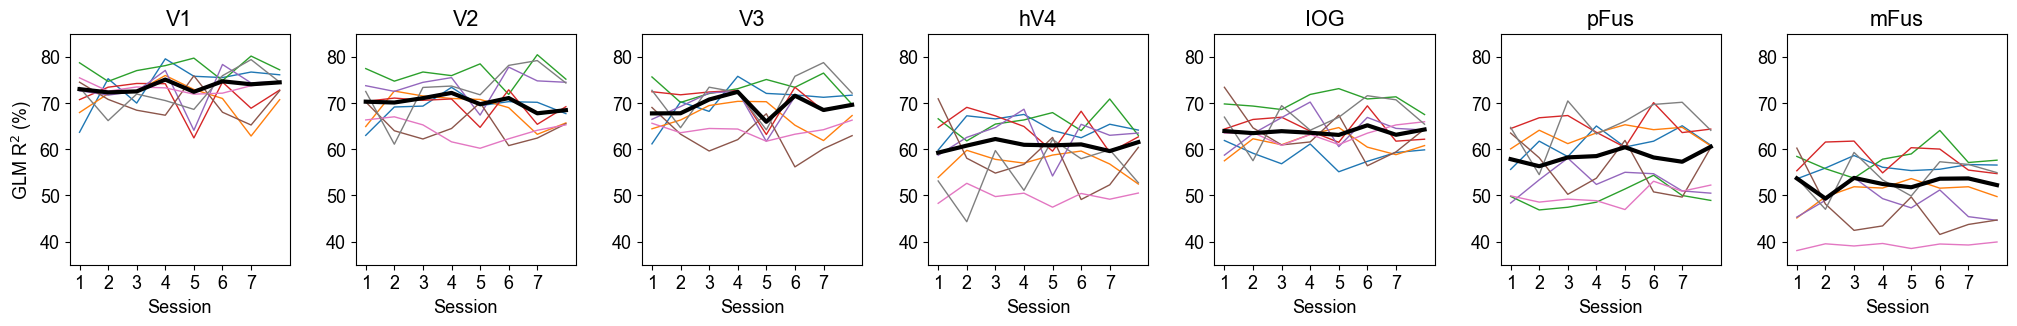

In [2]:
mglm_r2 = np.nanmedian(glm_r2_all,axis=2)*100 # subj x roi x session

# test
# anova
ps = []
for roi_i, roi in enumerate(roi_labels):
    data = mglm_r2[:,roi_i,:]
    df = pd.DataFrame({
        'subject': np.repeat(np.arange(nsubj), nsess),
        'session': np.tile(np.arange(nsess), nsubj),
        'value': data.flatten()
    })
    df = df.dropna()
    aov = pingouin.rm_anova(data=df, dv='value', within='session', subject='subject', detailed=True)
    ps.append(aov['p-unc'].iloc[0])

ps_f = multipletests(ps,method='bonferroni')[1]
print('ANOVA results: {}'.format(ps_f))

# lmm
ps_lmm = []
coef_lmm = []
for roi_i, roi in enumerate(roi_labels):
    data = mglm_r2[:,roi_i,:]
    df = pd.DataFrame({
        'subject': np.repeat(np.arange(nsubj), nsess),
        'session': np.tile(np.arange(nsess), nsubj),
        'value': data.flatten()
    })
    df = df.dropna()
    model = smf.mixedlm(
        "value ~ session",
        df,
        groups=df["subject"]
    )
    res = model.fit()
    ps_lmm.append(round(float(res.pvalues['session']),4))
    coef_lmm.append(round(float(res.params['session']),4))
ps_lmm_f = multipletests(ps_lmm,method='bonferroni')[1]
print('LMM results: \n p\t{} \n coef\t{}'.format(ps_lmm_f,coef_lmm))


# plot
import matplotlib.pyplot as plt
colors = plt.get_cmap('tab10').colors # 10 colors
set_figure()
fig,axes = plt.subplots(1,7,figsize=(25,3),gridspec_kw={'wspace': 0.3})
for roi_i, roi in enumerate(roi_labels):
    ax = axes[roi_i]
    data = mglm_r2[:,roi_i,:]
    xx = np.zeros_like(data)+np.arange(1,1+nsess)
    for subj_i in range(mglm_r2.shape[0]):
        ax.plot(xx[subj_i], data[subj_i],linewidth=1,color=colors[subj_i],alpha=1)
    #ax.plot(xx.T, data.T,linewidth=1,color='k',alpha=0.5)
    #[mdata,edata,_] = stat_m_e(data,'mean','sem')
    #ax.errorbar(np.arange(1,1+nsess),mdata,edata,color="k",alpha=0.8,linestyle=' ')
    #ax.bar(np.arange(1,1+nsess),mdata,color="grey")
    ax.plot(np.arange(1,1+nsess),np.nanmedian(data,axis=0),color='k',linewidth=3)
    ax.set_xticks(np.arange(1,nsess))
    ax.set_ylim(35,85)
    ax.set_xlabel('Session')
    ax.set_title(roi)
axes[0].set_ylabel('GLM R$^2$ (%)')

fig.savefig('figures/figS10-glmr2.pdf', bbox_inches='tight')

### 2. mean response

ANOVA results: 
 Digit Task:[1. 1. 1. 1. 1. 1. 1.] 
 Face Task:[0.45441025 0.19820316 0.02590148 0.40659729 1.         1.
 1.        ]


d:\MySoftwares\anaconda3\envs\py311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


LMM results: 
 Digit Task 
 p	[1. 1. 1. 1. 1. 1. 1.] 
 coef	[-0.0007, -0.0031, 0.0068, -0.0048, 0.0078, 0.0158, 0.0149] 
 Face Task 
 p	[1.     1.     1.     1.     0.5327 1.     0.3955] 
 coef	[-0.0014, -0.0013, 0.0026, 0.001, 0.0111, 0.0095, 0.0113]


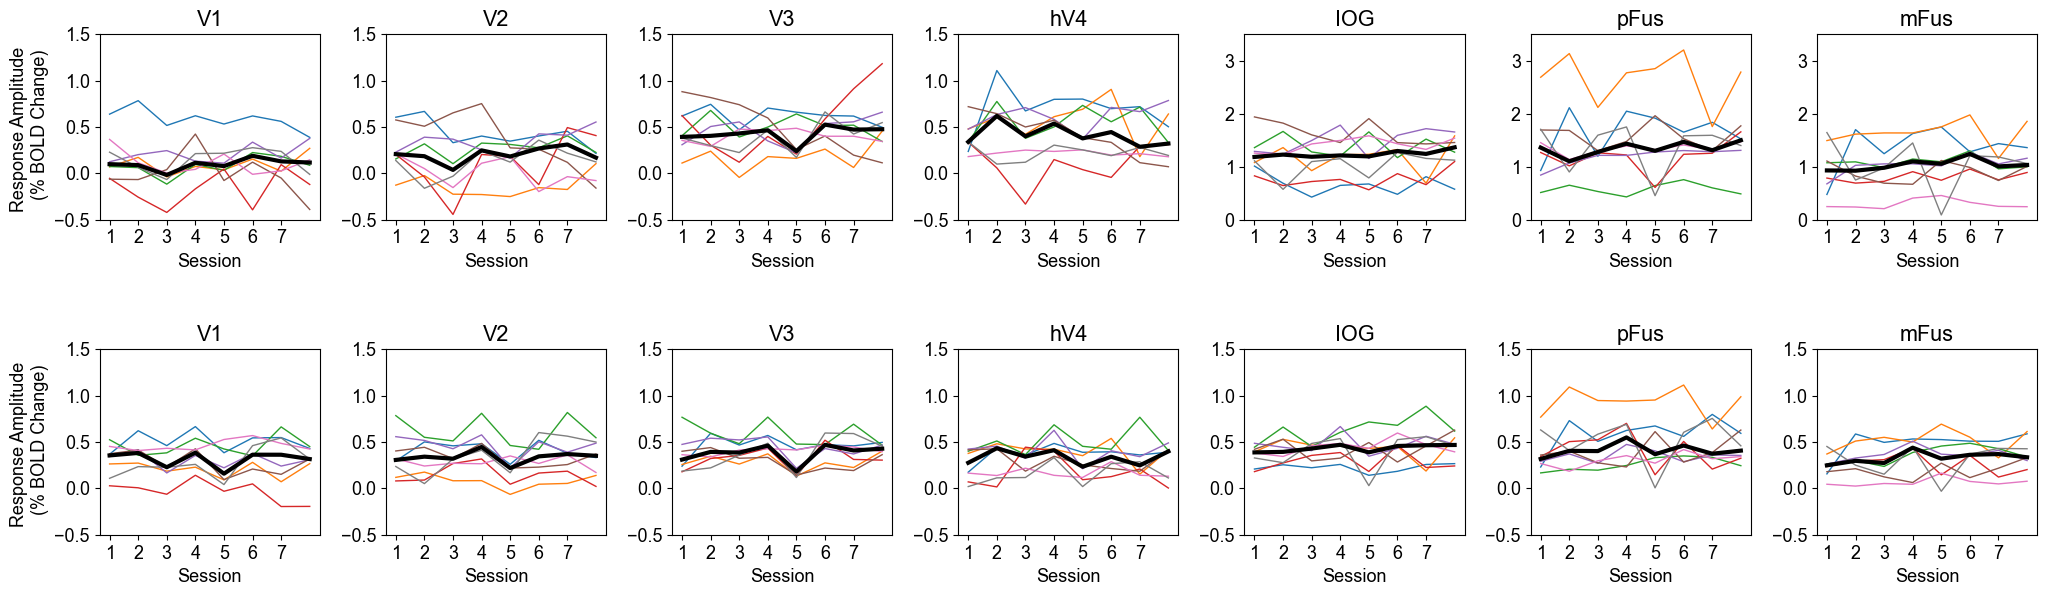

In [3]:
# mean response: 
r_session = np.nanmean(beta_session,axis=-1) # 2 x 7 x 8subj x 8sess x 100
mr_session = np.nanmedian(r_session,axis=-1) # 2 x 7 x 8subj x 8sess

# test
ps = [[],[]]
ps_f = [[],[]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        data = mr_session[task_i,roi_i,:,:]
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': data.flatten()
        })
        df = df.dropna()
        aov = pingouin.rm_anova(data=df, dv='value', within='session', subject='subject', detailed=True)
        ps[task_i].append(aov['p-unc'].iloc[0])

    ps_f[task_i] = multipletests(ps[task_i],method='bonferroni')[1]
print('ANOVA results: \n {}:{} \n {}:{}'.format(task[0],ps_f[0],task[1],ps_f[1]))

# lmm
ps_lmm = [[],[]]
ps_lmm_f = [[],[]]
coef_lmm = [[],[]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        data = mr_session[task_i,roi_i,:,:]
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': data.flatten()
        })
        df = df.dropna()
        model = smf.mixedlm(
            "value ~ session",
            df,
            groups=df["subject"]
        )
        res = model.fit()
        ps_lmm[task_i].append(round(float(res.pvalues['session']),4))
        coef_lmm[task_i].append(round(float(res.params['session']),4))
    
    ps_lmm_f[task_i] = multipletests(ps_lmm[task_i],method='bonferroni')[1]
print('LMM results: \n {} \n p\t{} \n coef\t{} \n {} \n p\t{} \n coef\t{}'.format(task[0],ps_lmm_f[0],coef_lmm[0],
        task[1],ps_lmm_f[1],coef_lmm[1]))


# plot
import matplotlib.pyplot as plt
colors = plt.get_cmap('tab10').colors # 10 colors
set_figure()
fig,axes = plt.subplots(2,7,figsize=(25,6.5),gridspec_kw={'wspace': 0.3,'hspace':0.7})
ylims = [[[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[0,3.5],[0,3.5],[0,3.5]],
        [[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5]]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        ax = axes[task_i,roi_i]
        data = mr_session[task_i,roi_i,:,:]
        xx = np.zeros_like(data)+np.arange(1,1+nsess)
        for subj_i in range(data.shape[0]):
            ax.plot(xx[subj_i], data[subj_i],linewidth=1,color=colors[subj_i],alpha=1)
        ax.plot(np.arange(1,1+nsess),np.nanmedian(data,axis=0),color='k',linewidth=3)
        #ax.plot(xx.T, data.T,linewidth=1,color='k',alpha=0.5)
        #[mdata,edata,_] = stat_m_e(data,'mean','sem')
        #ax.errorbar(np.arange(1,1+nsess),mdata,edata,color="k",alpha=0.8,linestyle=' ')
        #ax.bar(np.arange(1,1+nsess),mdata,color="grey")
        ax.set_xticks(np.arange(1,nsess))
        ax.set_ylim(ylims[task_i][roi_i][0],ylims[task_i][roi_i][1])
        ax.set_xlabel('Session')
        ax.set_title(roi)
    #axes[task_i,0].legend(['Sub{:d}'.format(i) for i in range(1,1+nsubj)],fontsize=10,frameon=True, ncol=2)
    axes[task_i,0].set_ylabel(f'Response Amplitude \n (% BOLD Change)')

fig.savefig('figures/figS10-amplitude.pdf')

ANOVA results: 
 Digit Task:[1.         1.         1.         0.84064606 1.         0.41290416
 1.        ] 
 Face Task:[1. 1. 1. 1. 1. 1. 1.]
LMM results: 
 Digit Task 
 p	[1.     1.     0.6951 1.     1.     1.     1.    ] 
 coef	[-0.015, -0.0514, -0.0473, -0.0388, 0.0014, -0.0137, -0.0243] 
 Face Task 
 p	[1.     0.3374 1.     1.     1.     1.     1.    ] 
 coef	[-0.0001, -0.0482, -0.0244, -0.0324, -0.0084, -0.0091, -0.0331]


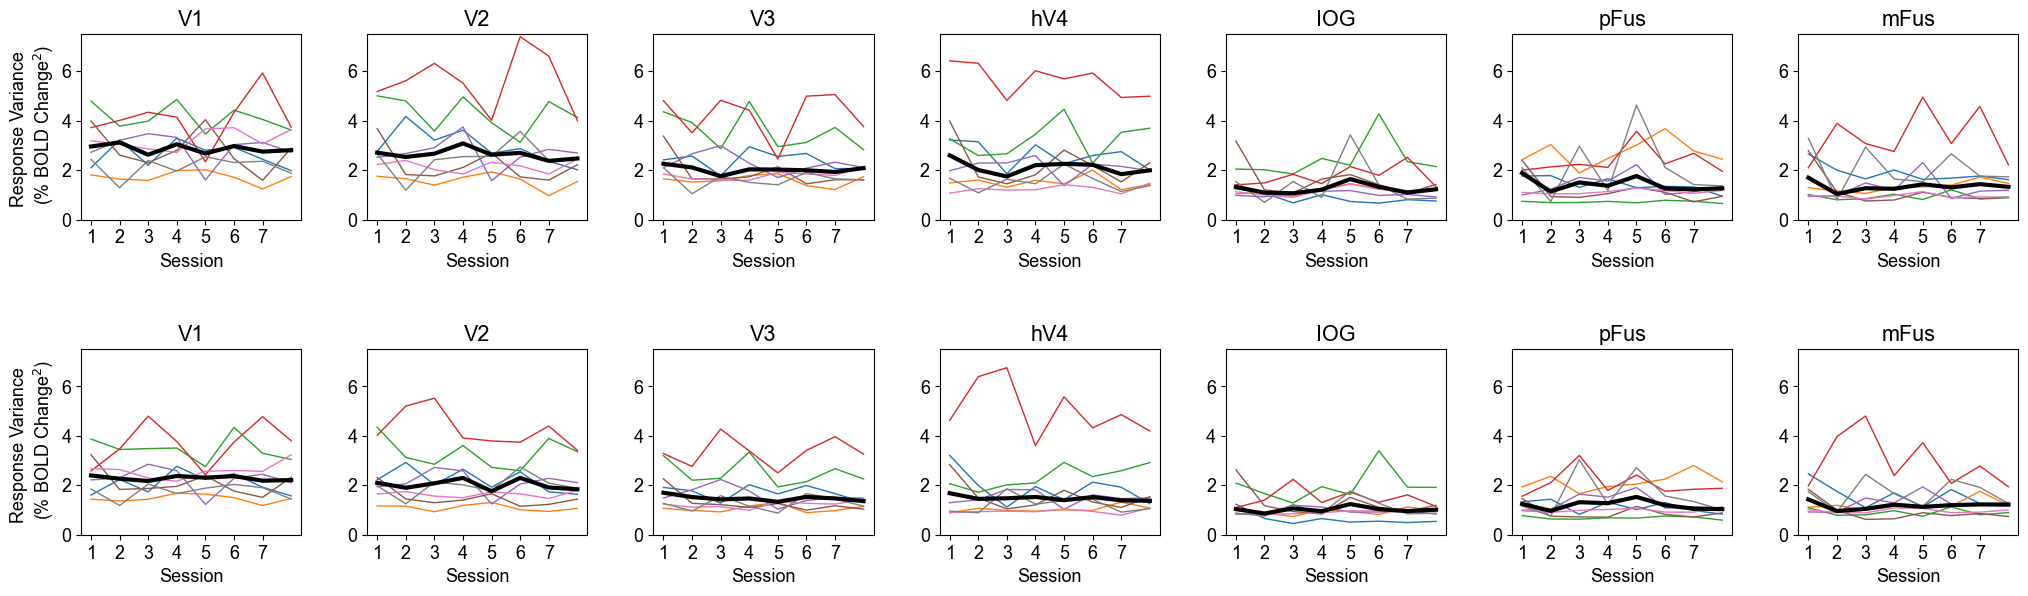

In [4]:
# response variability: 
var_session = np.nanvar(beta_session,axis=-1) # 2 x 7 x 8subj x 8sess x 100
mvar_session = np.nanmedian(var_session,axis=-1) # 2 x 7 x 8subj x 8sess

# test
ps = [[],[]]
ps_f = [[],[]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        data = mvar_session[task_i,roi_i,:,:]
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': data.flatten()
        })
        df = df.dropna()
        aov = pingouin.rm_anova(data=df, dv='value', within='session', subject='subject', detailed=True)
        ps[task_i].append(aov['p-unc'].iloc[0])

    ps_f[task_i] = multipletests(ps[task_i],method='bonferroni')[1]
print('ANOVA results: \n {}:{} \n {}:{}'.format(task[0],ps_f[0],task[1],ps_f[1]))

# lmm
ps_lmm = [[],[]]
ps_lmm_f = [[],[]]
coef_lmm = [[],[]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        data = mvar_session[task_i,roi_i,:,:]
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': data.flatten()
        })
        df = df.dropna()
        model = smf.mixedlm(
            "value ~ session",
            df,
            groups=df["subject"]
        )
        res = model.fit()
        ps_lmm[task_i].append(round(float(res.pvalues['session']),4))
        coef_lmm[task_i].append(round(float(res.params['session']),4))
    
    ps_lmm_f[task_i] = multipletests(ps_lmm[task_i],method='bonferroni')[1]
print('LMM results: \n {} \n p\t{} \n coef\t{} \n {} \n p\t{} \n coef\t{}'.format(task[0],ps_lmm_f[0],coef_lmm[0],
        task[1],ps_lmm_f[1],coef_lmm[1]))

# plot
import matplotlib.pyplot as plt
colors = plt.get_cmap('tab10').colors # 10 colors
set_figure()
fig,axes = plt.subplots(2,7,figsize=(25,6.5),gridspec_kw={'wspace': 0.3,'hspace':0.7})
ylims = [[[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[0,3.5],[0,3.5],[0,3.5]],
        [[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5],[-0.5,1.5]]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        ax = axes[task_i,roi_i]
        data = mvar_session[task_i,roi_i,:,:]
        xx = np.zeros_like(data)+np.arange(1,1+nsess)
        for subj_i in range(data.shape[0]):
            ax.plot(xx[subj_i], data[subj_i],linewidth=1,color=colors[subj_i],alpha=1)
        ax.plot(np.arange(1,1+nsess),np.nanmedian(data,axis=0),color='k',linewidth=3)
        #ax.plot(xx.T, data.T,linewidth=1,color='k',alpha=0.5)
        #[mdata,edata,_] = stat_m_e(data,'mean','sem')
        #ax.errorbar(np.arange(1,1+nsess),mdata,edata,color="k",alpha=0.8,linestyle=' ')
        #ax.bar(np.arange(1,1+nsess),mdata,color="grey")
        ax.set_xticks(np.arange(1,nsess))
        ax.set_ylim(0,7.5)
        ax.set_xlabel('Session')
        ax.set_title(roi)
    axes[task_i,0].set_ylabel(f'Response Variance \n (% BOLD Change$^2$)')

fig.savefig('figures/figS10-variance.pdf')

ANOVA results: 
 Digit Task:[1.         1.         0.48222745 0.77233278 1.         0.95598685
 1.        ] 
 Face Task:[1.         1.         0.20611745 0.67768165 1.         1.
 1.        ]


d:\MySoftwares\anaconda3\envs\py311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\MySoftwares\anaconda3\envs\py311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\MySoftwares\anaconda3\envs\py311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\MySoftwares\anaconda3\envs\py311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\MySoftwares\anaconda3\envs\py311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: Convergence

LMM results: 
 Digit Task 
 p	[0.1022 0.9597 1.     1.     0.5159 1.     1.    ] 
 coef	[-0.0061, -0.0038, -0.0027, -0.0008, -0.0049, 0.0017, 0.0011] 
 Face Task 
 p	[1.     1.     1.     1.     0.8841 1.     1.    ] 
 coef	[0.0007, 0.0018, 0.003, 0.0021, 0.0052, 0.0061, 0.0014]


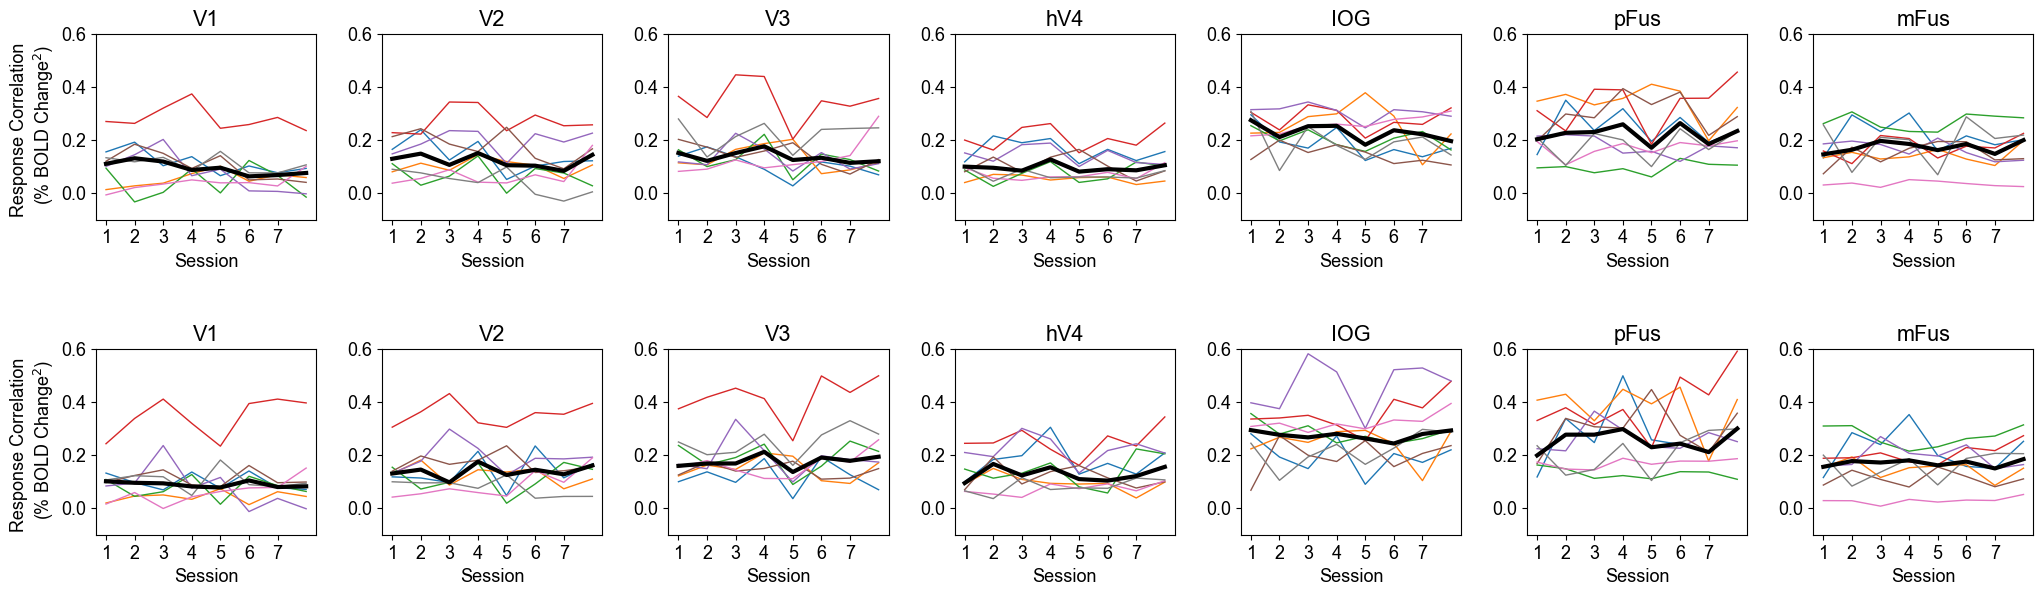

In [5]:
# response correlation: 
corr_session = corr_batch_nan(beta_session,ctype='corr',ddof=1) # 2 x 7 x 8 x 8 x 100 x 100
triu_idx = np.triu_indices(beta_session.shape[-2],k=1)
corr_triu = corr_session[...,triu_idx[0],triu_idx[1]] # 2 x 7 x 8 x 8 x 4950
mcorr_session = np.nanmedian(corr_triu,axis=-1) # 2 x 7 x 8 x 8
mcorr_session_fisherz = fisherztrans(mcorr_session)

# test
ps = [[],[]]
ps_f = [[],[]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        data = mcorr_session_fisherz[task_i,roi_i,:,:]
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': data.flatten()
        })
        df = df.dropna()
        aov = pingouin.rm_anova(data=df, dv='value', within='session', subject='subject', detailed=True)
        ps[task_i].append(aov['p-unc'].iloc[0])

    ps_f[task_i] = multipletests(ps[task_i],method='bonferroni')[1]
print('ANOVA results: \n {}:{} \n {}:{}'.format(task[0],ps_f[0],task[1],ps_f[1]))

# lmm
ps_lmm = [[],[]]
ps_lmm_f = [[],[]]
coef_lmm = [[],[]]
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        data = mcorr_session_fisherz[task_i,roi_i,:,:]
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': data.flatten()
        })
        df = df.dropna()
        model = smf.mixedlm(
            "value ~ session",
            df,
            groups=df["subject"]
        )
        res = model.fit()
        ps_lmm[task_i].append(round(float(res.pvalues['session']),4))
        coef_lmm[task_i].append(round(float(res.params['session']),4))
    
    ps_lmm_f[task_i] = multipletests(ps_lmm[task_i],method='bonferroni')[1]
print('LMM results: \n {} \n p\t{} \n coef\t{} \n {} \n p\t{} \n coef\t{}'.format(task[0],ps_lmm_f[0],coef_lmm[0],
        task[1],ps_lmm_f[1],coef_lmm[1]))


# plot
import matplotlib.pyplot as plt
colors = plt.get_cmap('tab10').colors # 10 colors
set_figure()
fig,axes = plt.subplots(2,7,figsize=(25,6.5),gridspec_kw={'wspace': 0.3,'hspace':0.7})
for task_i in range(ntask):
    for roi_i, roi in enumerate(roi_labels):
        ax = axes[task_i,roi_i]
        data = mcorr_session_fisherz[task_i,roi_i,:,:]
        xx = np.zeros_like(data)+np.arange(1,1+nsess)
        for subj_i in range(data.shape[0]):
            ax.plot(xx[subj_i], data[subj_i],linewidth=1,color=colors[subj_i],alpha=1)
        ax.plot(np.arange(1,1+nsess),np.nanmedian(data,axis=0),color='k',linewidth=3)
        #ax.plot(xx.T, data.T,linewidth=1,color='k',alpha=0.5)
        #[mdata,edata,_] = stat_m_e(data,'mean','sem')
        #ax.errorbar(np.arange(1,1+nsess),mdata,edata,color="k",alpha=0.8,linestyle=' ')
        #ax.bar(np.arange(1,1+nsess),mdata,color="grey")
        ax.set_xticks(np.arange(1,nsess))
        ax.set_ylim(-0.1,0.6)
        ax.set_xlabel('Session')
        ax.set_title(roi)
    axes[task_i,0].set_ylabel(f'Response Correlation \n (% BOLD Change$^2$)')

fig.savefig('figures/figS10-correlation.pdf')